In [1]:
# ==================================================
# 🚀 Colab Setup: Clone Repo & Mount Drive
# ==================================================

# Clone the repository
!git clone https://github.com/rahulmkarthik/VolSense.git
%cd VolSense

# Checkout the correct branch
!git checkout feature/CQF-backtest

# Install dependencies (if needed)
!pip install -q torch tqdm pandas numpy matplotlib seaborn scikit-learn

# Add repo to Python path
import sys
sys.path.insert(0, '/content/VolSense')

# Mount Google Drive for dataset access
from google.colab import drive
drive.mount('/content/drive')

# Verify setup
import os
print("✅ Repository cloned and ready")
print(f"   Current directory: {os.getcwd()}")
print(f"   Contents: {os.listdir('.')[:10]}...")

# Check GPU availability
import torch
print(f"\n📌 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📌 GPU: {torch.cuda.get_device_name(0)}")

Cloning into 'VolSense'...
remote: Enumerating objects: 1657, done.
remote: Counting objects: 100% (181/181), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 1657 (delta 63), reused 104 (delta 45), pack-reused 1476 (from 1)
Receiving objects: 100% (1657/1657), 53.34 MiB | 21.53 MiB/s, done.
Resolving deltas: 100% (944/944), done.
/content/VolSense
Branch 'feature/CQF-backtest' set up to track remote branch 'feature/CQF-backtest' from 'origin'.
Switched to a new branch 'feature/CQF-backtest'
Mounted at /content/drive
✅ Repository cloned and ready
   Current directory: /content/VolSense
   Contents: ['README.md', 'MANIFEST.in', '.gitattributes', 'dist', 'pyproject.toml', 'docs', 'reports', '.git', 'volsense_core', '.gitignore']...

📌 CUDA available: True
📌 GPU: Tesla T4


# 📊 VolNetX Comprehensive Evaluation
This notebook evaluates the VolNetX model using both **regression metrics** (RMSE, MAE, R²) and **classification metrics** (AUC-ROC, balanced accuracy, confusion matrix) for volatility direction prediction.
## Contents
1. Model & Data Loading
2. Inference on Validation Set
3. Regression Metrics (per horizon)
4. Direction Classification Metrics
5. Confusion Matrices & Classification Reports
6. Trading Strategy Backtest
7. Summary Table for CQF Report

In [2]:
# ==================================================
# 📦 Imports
# ==================================================
import os
import sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm.auto import tqdm
# Add repo root to path
sys.path.insert(0, os.path.abspath(".."))
# VolSense imports
from volsense_inference.model_loader import load_model
from volsense_core.evaluation.evaluation import ModelEvaluator
from volsense_execution.backtest import VolatilityDirectionBacktest, run_backtest_from_evaluator
# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
plt.style.use("seaborn-v0_8-whitegrid")
print("✅ Imports complete")

✅ Imports complete


In [19]:
# ==================================================
# ⚙️ Configuration
# ==================================================
MODEL_VERSION = "volnetx"
CHECKPOINTS_DIR = "models"
DATASET_PATH = "/content/drive/MyDrive/VolNetX_training_data/unzipped/master_lstm_dataset_v2.csv"
VAL_START_DATE = "2024-01-01"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WINDOW = 65
HORIZONS = [1, 5, 10]

print(f"📌 Model: {MODEL_VERSION}")
print(f"📌 Device: {DEVICE}")  # Should print "cuda" on Colab
print(f"📌 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📌 GPU: {torch.cuda.get_device_name(0)}")

📌 Model: volnetx
📌 Device: cuda
📌 CUDA available: True
📌 GPU: Tesla T4


In [4]:
# ==================================================
# 🧠 Load VolNetX Model
# ==================================================
model, meta, scalers, ticker_to_id, features = load_model(
    MODEL_VERSION,
    checkpoints_dir=CHECKPOINTS_DIR,
    device=DEVICE
)
print(f"✅ Loaded model: {meta.get('arch', 'Unknown')}")
print(f"   Window: {meta.get('window', WINDOW)}")
print(f"   Horizons: {meta.get('horizons', HORIZONS)}")
print(f"   Features ({len(features)}): {features}")
print(f"   Tickers: {len(ticker_to_id)}")
print(f"   Scalers available: {scalers is not None}")

✅ Loaded model: VolNetX
   Window: 65
   Horizons: [1, 5, 10]
   Features (23): ['return', 'vol_10d', 'vol_20d', 'vol_60d', 'vol_3d', 'vol_vol', 'vol_ratio', 'vol_chg', 'abs_return', 'market_stress', 'vol_stress', 'rsi_14', 'macro_VIX', 'macro_CreditSpread', 'macro_Curve', 'macro_USD', 'event_earnings_heat', 'macro_Oil', 'macro_Rates', 'macro_BTC', 'return_sharpe_20d', 'skew_5d', 'skew_scaled_return']
   Tickers: 507
   Scalers available: True


In [20]:
# ==================================================
# 📂 Load Dataset
# ==================================================
df = pd.read_csv(DATASET_PATH)
df["date"] = pd.to_datetime(df["date"])
# Show date range
print(f"📊 Dataset shape: {df.shape}")
print(f"   Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"   Tickers: {df['ticker'].nunique()}")
# Filter to validation period
val_df = df[df["date"] >= VAL_START_DATE].copy()
print(f"\n📌 Validation set: {len(val_df):,} rows from {VAL_START_DATE}")
print(f"   Validation date range: {val_df['date'].min().date()} to {val_df['date'].max().date()}")

📊 Dataset shape: (2378068, 38)
   Date range: 2005-01-25 to 2025-10-23
   Tickers: 509

📌 Validation set: 229,646 rows from 2024-01-01
   Validation date range: 2024-01-01 to 2025-10-23


## 🔮 Model Inference
Running VolNetX inference on the validation set. For each ticker, we:
1. Extract the feature window (last 65 days)
2. Apply per-ticker scaling
3. Run forward pass to get predictions for all horizons

In [23]:
# ==================================================
# 🔮 Run Inference
# ==================================================

def run_volnetx_inference_vectorized(val_df, full_df, model, scalers, ticker_to_id, features, device, window=65):
    """
    Fully vectorized VolNetX inference - pre-builds all windows, then batch processes.
    """
    model.eval()

    # ==== STEP 1: Pre-build all (ticker, date) window tensors ====
    print("📦 Pre-building feature windows...")

    # Ensure consistent date types
    full_df = full_df.copy()
    full_df["date"] = pd.to_datetime(full_df["date"])
    val_df = val_df.copy()
    val_df["date"] = pd.to_datetime(val_df["date"])

    full_df = full_df.sort_values(["ticker", "date"]).reset_index(drop=True)
    val_dates = sorted(val_df["date"].unique())

    # Pre-extract feature matrix per ticker
    ticker_feature_cache = {}
    ticker_dates = {}  # Store dates as list for index lookup

    for ticker in tqdm(ticker_to_id.keys(), desc="Caching ticker data"):
        tdf = full_df[full_df["ticker"] == ticker][["date"] + features].copy()
        if len(tdf) < window:
            continue
        tdf = tdf.sort_values("date").reset_index(drop=True)
        ticker_feature_cache[ticker] = tdf[features].values.astype(np.float32)
        ticker_dates[ticker] = tdf["date"].tolist()  # List of Timestamps

    # ==== STEP 2: Build valid samples ====
    print("🔧 Building inference samples...")

    samples = []

    # Pre-fetch today_vol lookup with string keys for reliability
    val_df["lookup_key"] = val_df["date"].astype(str) + "_" + val_df["ticker"]
    val_vol_lookup = val_df.set_index("lookup_key")["realized_vol_log"].to_dict()

    for asof_date in tqdm(val_dates, desc="Preparing windows"):
        asof_str = str(asof_date)[:10]  # "2024-01-15"

        for ticker in ticker_to_id.keys():
            if ticker not in ticker_dates:
                continue

            dates_list = ticker_dates[ticker]
            feature_arr = ticker_feature_cache[ticker]

            # Find index of asof_date in this ticker's dates
            try:
                # Find the date in the list (handle timezone-naive comparison)
                idx = None
                for i, d in enumerate(dates_list):
                    if str(d)[:10] == asof_str:
                        idx = i
                        break

                if idx is None or idx < window - 1:
                    continue

            except Exception:
                continue

            # Extract window
            X_window = feature_arr[idx - window + 1 : idx + 1]

            if len(X_window) != window:
                continue

            # Get today vol
            lookup_key = f"{asof_str}_{ticker}"
            if lookup_key not in val_vol_lookup:
                # Try alternative date format
                lookup_key = f"{asof_date}_{ticker}"
                if lookup_key not in val_vol_lookup:
                    continue

            today_vol = np.exp(val_vol_lookup[lookup_key])
            samples.append((asof_date, ticker, X_window, today_vol))

    print(f"✅ Built {len(samples):,} inference samples")

    if len(samples) == 0:
        # Debug info
        print("\n⚠️ DEBUG: No samples found!")
        print(f"   val_dates sample: {val_dates[:3]}")
        print(f"   ticker_dates sample (first ticker): {list(ticker_dates.values())[0][:3] if ticker_dates else 'empty'}")
        print(f"   val_vol_lookup keys sample: {list(val_vol_lookup.keys())[:3]}")
        return pd.DataFrame()

    # ==== STEP 3: Batch inference ====
    print("🚀 Running batched GPU inference...")

    BATCH_SIZE = 512
    all_preds = []

    for batch_start in tqdm(range(0, len(samples), BATCH_SIZE), desc="Inference batches"):
        batch = samples[batch_start : batch_start + BATCH_SIZE]

        X_batch = np.stack([s[2] for s in batch])
        ticker_ids = [ticker_to_id[s[1]] for s in batch]

        # Apply per-ticker scaling
        X_scaled = np.zeros_like(X_batch)
        for i, (_, ticker, _, _) in enumerate(batch):
            if scalers and ticker in scalers:
                sc = scalers[ticker]
                X_t = torch.tensor(X_batch[i], dtype=torch.float32)
                X_s = sc.transform(X_t)
                X_scaled[i] = X_s.numpy() if isinstance(X_s, torch.Tensor) else X_s
            else:
                X_scaled[i] = X_batch[i]

        X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)
        idx_tensor = torch.tensor(ticker_ids, dtype=torch.long).to(device)

        with torch.no_grad():
            preds = model(idx_tensor, X_tensor)

        all_preds.append(preds.cpu().numpy())

    all_preds = np.vstack(all_preds)

    # ==== STEP 4: Collect results ====
    print("📊 Collecting results...")

    results = []

    for i, (asof_date, ticker, _, today_vol) in enumerate(samples):
        asof_str = str(asof_date)[:10]

        for h_idx, h in enumerate(HORIZONS):
            future_date = asof_date + pd.Timedelta(days=h)

            # Look up realized vol with weekend handling
            realized_vol = np.nan
            for offset in range(7):
                check_date = future_date + pd.Timedelta(days=offset)
                check_key = f"{str(check_date)[:10]}_{ticker}"
                if check_key in val_vol_lookup:
                    realized_vol = np.exp(val_vol_lookup[check_key])
                    break

            forecast_vol = np.exp(all_preds[i, h_idx])

            results.append({
                "date": asof_date,
                "ticker": ticker,
                "horizon": h,
                "forecast_vol": forecast_vol,
                "realized_vol": realized_vol,
                "today_vol": today_vol,
            })

    return pd.DataFrame(results)

# ==== RUN ====
print("🔮 Running VECTORIZED VolNetX inference...")
eval_df = run_volnetx_inference_vectorized(
    val_df, df, model, scalers, ticker_to_id, features, DEVICE, WINDOW
)
print(f"✅ Inference complete: {len(eval_df):,} predictions")
eval_df.head(10)

🔮 Running VECTORIZED VolNetX inference...
📦 Pre-building feature windows...


Caching ticker data:   0%|          | 0/507 [00:00<?, ?it/s]

🔧 Building inference samples...


Preparing windows:   0%|          | 0/662 [00:00<?, ?it/s]

✅ Built 228,738 inference samples
🚀 Running batched GPU inference...


Inference batches:   0%|          | 0/447 [00:00<?, ?it/s]

📊 Collecting results...
✅ Inference complete: 686,214 predictions


,date,ticker,horizon,forecast_vol,realized_vol,today_vol
0,2024-01-01,BTC-USD,1,0.3087,0.3123,0.3265
1,2024-01-01,BTC-USD,5,0.3184,0.3709,0.3265
2,2024-01-01,BTC-USD,10,0.3287,0.4432,0.3265
3,2024-01-01,ETH-USD,1,0.4050,0.3941,0.3945
4,2024-01-01,ETH-USD,5,0.4213,0.4497,0.3945
5,2024-01-01,ETH-USD,10,0.4050,0.5764,0.3945
6,2024-01-02,AAPL,1,0.1845,0.1816,0.1853
7,2024-01-02,AAPL,5,0.1891,0.1954,0.1853
8,2024-01-02,AAPL,10,0.2057,0.1937,0.1853
9,2024-01-02,ABNB,1,0.2979,0.2561,0.2686


In [24]:
# ==================================================
# 📊 Initialize ModelEvaluator
# ==================================================
# Drop rows with missing realized_vol (future dates not available)
eval_df_clean = eval_df.dropna(subset=["realized_vol", "forecast_vol"])
print(f"📊 Evaluation set: {len(eval_df_clean):,} valid predictions")
evaluator = ModelEvaluator(eval_df_clean, model_name="VolNetX")
print("✅ ModelEvaluator initialized")

📊 Evaluation set: 680,173 valid predictions
✅ ModelEvaluator initialized


## 📈 Regression Performance Metrics
Evaluating continuous volatility prediction using:
- **RMSE**: Root Mean Squared Error
- **MAE**: Mean Absolute Error  
- **MAPE**: Mean Absolute Percentage Error
- **R²**: Coefficient of Determination
- **Correlation**: Pearson correlation between forecast and realized

In [25]:
# ==================================================
# 📈 Regression Metrics
# ==================================================
# Compute per-ticker, per-horizon metrics
metrics_df = evaluator.compute_metrics()
print(f"✅ Computed metrics for {len(metrics_df)} ticker-horizon combinations")
# Summarize by horizon
evaluator.summarize()

✅ Computed metrics for 1509 ticker-horizon combinations

📈 Horizon-Level Summary for VolNetX


,horizon,RMSE,MAE,MAPE,R2,Corr,DW
0,1,0.0433,0.0275,8.6353,0.8629,0.9675,0.7314
1,5,0.0684,0.0417,13.3845,0.6662,0.8627,0.4581
2,10,0.0970,0.0613,19.5187,0.3512,0.6708,0.2545


,horizon,RMSE,MAE,MAPE,R2,Corr,DW
0,1,0.0433,0.0275,8.6353,0.8629,0.9675,0.7314
1,5,0.0684,0.0417,13.3845,0.6662,0.8627,0.4581
2,10,0.0970,0.0613,19.5187,0.3512,0.6708,0.2545


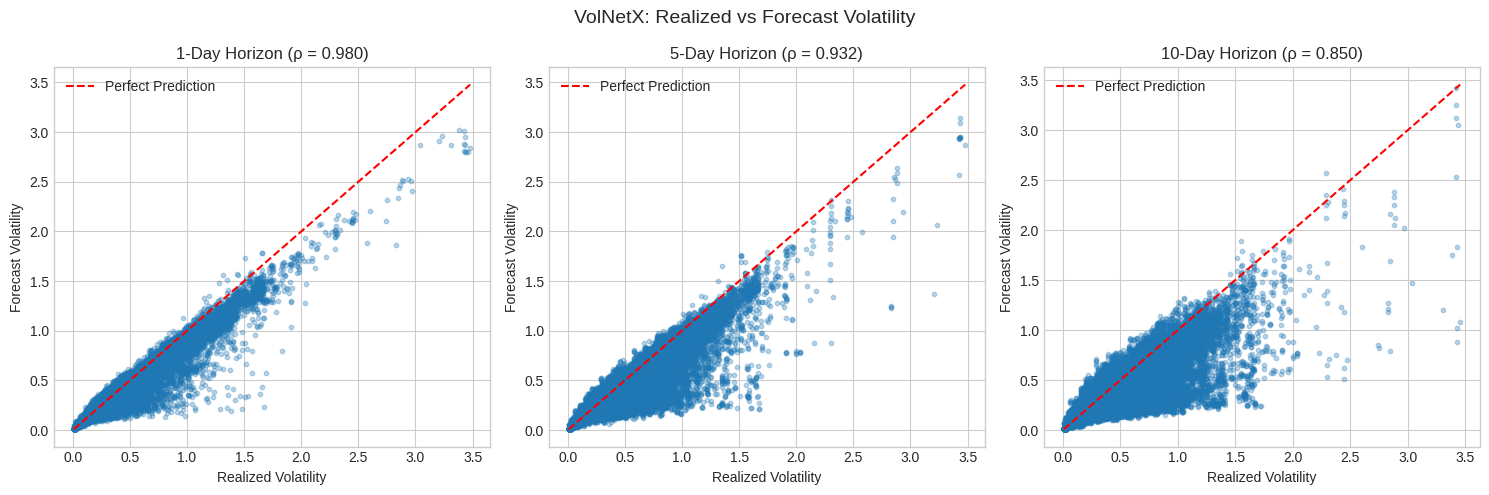

In [26]:
# ==================================================
# 📊 Visualization: True vs Predicted
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, h in enumerate(HORIZONS):
    ax = axes[i]
    hdf = eval_df_clean[eval_df_clean["horizon"] == h]

    ax.scatter(hdf["realized_vol"], hdf["forecast_vol"], alpha=0.3, s=10)

    lims = [
        min(hdf["realized_vol"].min(), hdf["forecast_vol"].min()),
        max(hdf["realized_vol"].max(), hdf["forecast_vol"].max())
    ]
    ax.plot(lims, lims, "r--", label="Perfect Prediction")

    # Compute R² for title
    corr = np.corrcoef(hdf["realized_vol"], hdf["forecast_vol"])[0, 1]
    ax.set_title(f"{h}-Day Horizon (ρ = {corr:.3f})")
    ax.set_xlabel("Realized Volatility")
    ax.set_ylabel("Forecast Volatility")
    ax.legend()
plt.suptitle("VolNetX: Realized vs Forecast Volatility", fontsize=14)
plt.tight_layout()
plt.show()

## 🎯 Direction Classification Metrics
Per CQF requirements, we evaluate the model's ability to correctly classify **volatility direction** (increase vs decrease).
Direction is derived from regression predictions:
- `y_true = 1` if realized_vol > today_vol (volatility increased)
- `y_pred = 1` if forecast_vol > today_vol (model predicts increase)
Metrics computed:
- **AUC-ROC**: Area under ROC curve
- **Balanced Accuracy**: Accounts for class imbalance
- **Precision / Recall / F1**: Per-class metrics
- **Confusion Matrix**: Visual breakdown of predictions

In [27]:
# ==================================================
# 🎯 Direction Classification Metrics
# ==================================================
# Compute direction metrics using the new ModelEvaluator methods
direction_metrics = evaluator.compute_direction_metrics(baseline_col="today_vol")
# Display summary
direction_summary = evaluator.summarize_direction()


🎯 Direction Classification Metrics for VolNetX
 horizon  accuracy  balanced_accuracy  precision  recall     f1  auc_roc  n_samples  class_balance
       1    0.5568             0.5588     0.6244  0.3019 0.4070   0.6060     228235         0.5038
       5    0.6526             0.6538     0.7023  0.5433 0.6127   0.7158     227226         0.5057
      10    0.6795             0.6808     0.7178  0.6109 0.6601   0.7416     224712         0.5093
Note: Direction = 1 if forecast_vol > baseline_vol (volatility increase)


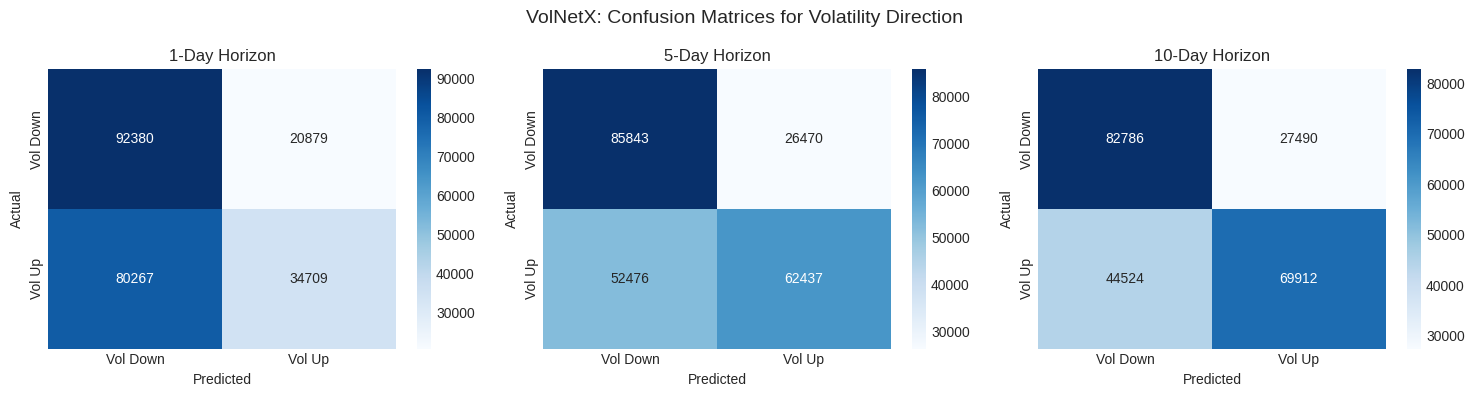

In [28]:
# ==================================================
# 📊 Confusion Matrices per Horizon
# ==================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, h in enumerate(HORIZONS):
    ax = axes[i]

    # Get confusion matrix
    hdf = eval_df_clean[eval_df_clean["horizon"] == h].copy()
    hdf["baseline_vol"] = hdf["today_vol"]
    hdf = hdf.dropna(subset=["baseline_vol", "forecast_vol", "realized_vol"])

    y_true = (hdf["realized_vol"] > hdf["baseline_vol"]).astype(int).values
    y_pred = (hdf["forecast_vol"] > hdf["baseline_vol"]).astype(int).values

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Vol Down", "Vol Up"],
        yticklabels=["Vol Down", "Vol Up"],
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{h}-Day Horizon")
plt.suptitle("VolNetX: Confusion Matrices for Volatility Direction", fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
# ==================================================
# 📊 Classification Reports
# ==================================================
for h in HORIZONS:
    evaluator.classification_report_text(h, baseline_col="today_vol")


📊 Classification Report – 1d Horizon
              precision    recall  f1-score   support

    Vol Down       0.54      0.82      0.65    113259
      Vol Up       0.62      0.30      0.41    114976

    accuracy                           0.56    228235
   macro avg       0.58      0.56      0.53    228235
weighted avg       0.58      0.56      0.53    228235


📊 Classification Report – 5d Horizon
              precision    recall  f1-score   support

    Vol Down       0.62      0.76      0.69    112313
      Vol Up       0.70      0.54      0.61    114913

    accuracy                           0.65    227226
   macro avg       0.66      0.65      0.65    227226
weighted avg       0.66      0.65      0.65    227226


📊 Classification Report – 10d Horizon
              precision    recall  f1-score   support

    Vol Down       0.65      0.75      0.70    110276
      Vol Up       0.72      0.61      0.66    114436

    accuracy                           0.68    224712
   macro avg 

## 💰 Trading Strategy Backtest
Evaluating the practical utility of direction predictions via a simple volatility trading strategy:
- **Long volatility** when model predicts vol increase
- **Short volatility** when model predicts vol decrease
Performance metrics:
- Cumulative Return
- Sharpe Ratio
- Maximum Drawdown
- Win Rate

In [ ]:
# ==================================================
# 💰 Enhanced Backtest (Diversity Weighted)
# ==================================================

# Initialize backtester
bt = VolatilityDirectionBacktest(eval_df)

# Run backtest for each horizon
results = {}

print(f"🚀 Running VolNetX Backtest (Aggregation: Diversity Weighted)...")
print("-" * 60)

for h in HORIZONS:
    # We pass 'model' so it can extract embeddings and compute
    # diversity scores (inverse correlation) for each ticker.
    res = bt.run_direction_backtest(
        horizon=h, 
        aggregation="diversity_weighted",  # <--- NEW MODE
        model=model                        # <--- Required for diversity mode
    )
    bt.summary()
    results[h] = res

# Plot cumulative returns for a representative horizon (e.g., 1d)
print("\n📈 Cumulative Returns (1-Day Horizon):")
bt.result = results[1] 
bt.plot_cumulative_returns()

# Plot Drawdowns
bt.plot_drawdown()

🎯 Running Direction Backtest (Horizon: 1d)

📊 VOLATILITY DIRECTION BACKTEST RESULTS
               Metric   Value
         Total Return 197.93%
    Annualized Return  51.71%
Annualized Volatility  12.30%
         Sharpe Ratio    3.88
        Sortino Ratio    3.24
         Max Drawdown -17.42%
             Win Rate  73.64%
        Profit Factor    2.44
         Calmar Ratio    2.97
         Trading Days     660


,Metric,Value
0,Total Return,197.93%
1,Annualized Return,51.71%
2,Annualized Volatility,12.30%
3,Sharpe Ratio,3.88
4,Sortino Ratio,3.24
5,Max Drawdown,-17.42%
6,Win Rate,73.64%
7,Profit Factor,2.44
8,Calmar Ratio,2.97
9,Trading Days,660


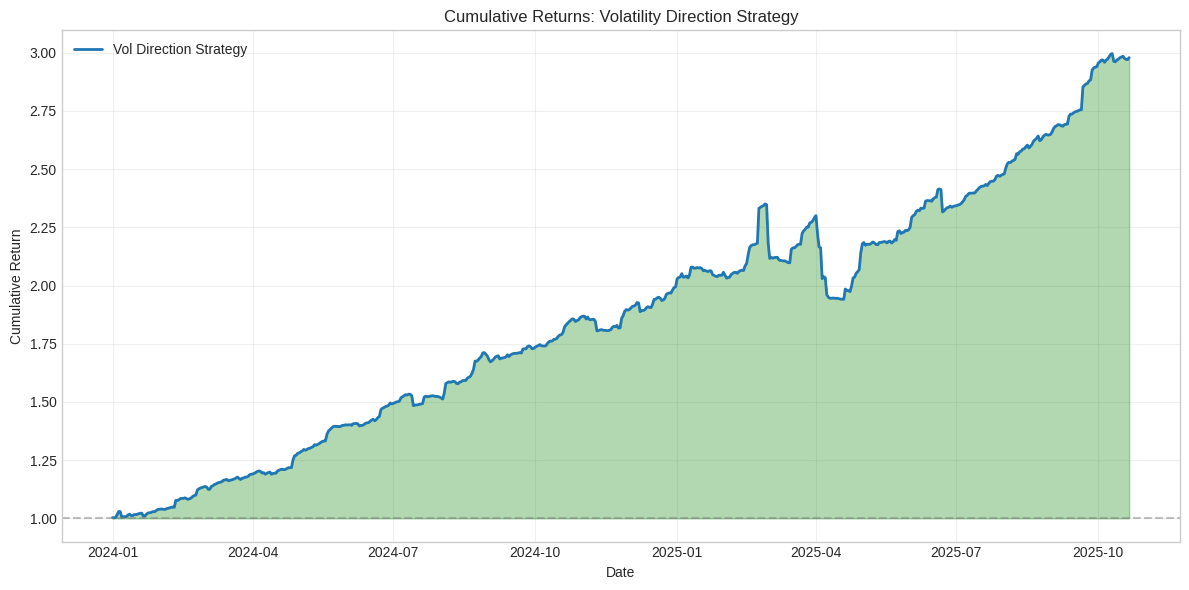

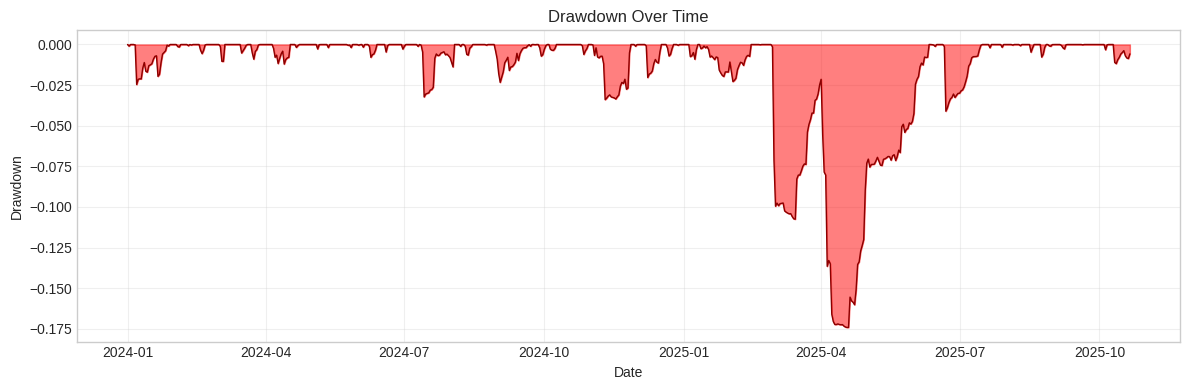

In [32]:
# ==================================================
# 📊 Backtest Visualizations
# ==================================================
# Cumulative returns
bt.plot_cumulative_returns()
# Drawdown
bt.plot_drawdown()

In [33]:
# ==================================================
# 📊 Backtest Comparison Across Horizons
# ==================================================
backtest_results = {}
for h in HORIZONS:
    bt_h = VolatilityDirectionBacktest(eval_df_clean)
    result = bt_h.run_direction_backtest(horizon=h)
    backtest_results[h] = result.metrics
# Create comparison table
bt_comparison = pd.DataFrame(backtest_results).T
bt_comparison.index.name = "Horizon"
bt_comparison = bt_comparison.reset_index()
print("\n📊 Backtest Comparison Across Horizons")
print("=" * 70)
display(bt_comparison.style.format({
    "total_return": "{:.2%}",
    "annualized_return": "{:.2%}",
    "annualized_volatility": "{:.2%}",
    "sharpe_ratio": "{:.2f}",
    "sortino_ratio": "{:.2f}",
    "max_drawdown": "{:.2%}",
    "win_rate": "{:.2%}",
    "profit_factor": "{:.2f}",
}))

🎯 Running Direction Backtest (Horizon: 1d)
🎯 Running Direction Backtest (Horizon: 5d)
🎯 Running Direction Backtest (Horizon: 10d)

📊 Backtest Comparison Across Horizons


,Horizon,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,win_rate,profit_factor,calmar_ratio,n_trading_days
0,1,197.93%,51.71%,12.30%,3.88,3.24,-17.42%,73.64%,2.44,2.968889,660.000000
1,5,163338.34%,1608.12%,24.99%,64.19,61.11,-12.64%,91.32%,10.08,127.231878,657.000000
2,10,9380099.43%,8251.71%,30.84%,267.46,307.36,-21.32%,90.34%,11.49,386.969977,652.000000


## 📋 Summary Table for CQF Report
The following tables provide formatted output suitable for inclusion in the LaTeX report.

In [34]:
# ==================================================
# 📋 Generate LaTeX Tables for Report
# ==================================================
print("=" * 70)
print("📊 REGRESSION METRICS TABLE (Copy to LaTeX)")
print("=" * 70)
# Aggregate by horizon
summary = evaluator.metrics_df.groupby("horizon").agg({
    "RMSE": "mean",
    "MAE": "mean",
    "MAPE": "mean",
    "R2": "mean",
    "Corr": "mean",
}).round(4)
print(summary.to_latex())
print("\n" + "=" * 70)
print("📊 DIRECTION CLASSIFICATION TABLE (Copy to LaTeX)")
print("=" * 70)
direction_table = pd.DataFrame([
    {
        "Horizon": f"{h}d",
        "AUC-ROC": m["auc_roc"],
        "Accuracy": m["accuracy"],
        "Balanced Acc.": m["balanced_accuracy"],
        "Precision": m["precision"],
        "Recall": m["recall"],
        "F1": m["f1"],
    }
    for h, m in evaluator.direction_metrics.items()
])
print(direction_table.to_latex(index=False, float_format="%.4f"))
print("\n" + "=" * 70)
print("📊 BACKTEST RESULTS TABLE (Copy to LaTeX)")
print("=" * 70)
backtest_table = pd.DataFrame([
    {
        "Horizon": f"{h}d",
        "Total Return": f"{m['total_return']:.2%}",
        "Ann. Sharpe": f"{m['sharpe_ratio']:.2f}",
        "Max DD": f"{m['max_drawdown']:.2%}",
        "Win Rate": f"{m['win_rate']:.2%}",
    }
    for h, m in backtest_results.items()
])
print(backtest_table.to_latex(index=False))

📊 REGRESSION METRICS TABLE (Copy to LaTeX)
\begin{tabular}{lrrrrr}
\toprule
 & RMSE & MAE & MAPE & R2 & Corr \\
horizon &  &  &  &  &  \\
\midrule
1 & 0.043300 & 0.027500 & 8.635300 & 0.862900 & 0.967500 \\
5 & 0.068400 & 0.041700 & 13.384500 & 0.666200 & 0.862700 \\
10 & 0.097000 & 0.061300 & 19.518700 & 0.351200 & 0.670800 \\
\bottomrule
\end{tabular}


📊 DIRECTION CLASSIFICATION TABLE (Copy to LaTeX)
\begin{tabular}{lrrrrrr}
\toprule
Horizon & AUC-ROC & Accuracy & Balanced Acc. & Precision & Recall & F1 \\
\midrule
1d & 0.6060 & 0.5568 & 0.5588 & 0.6244 & 0.3019 & 0.4070 \\
5d & 0.7158 & 0.6526 & 0.6538 & 0.7023 & 0.5433 & 0.6127 \\
10d & 0.7416 & 0.6795 & 0.6808 & 0.7178 & 0.6109 & 0.6601 \\
\bottomrule
\end{tabular}


📊 BACKTEST RESULTS TABLE (Copy to LaTeX)
\begin{tabular}{lllll}
\toprule
Horizon & Total Return & Ann. Sharpe & Max DD & Win Rate \\
\midrule
1d & 197.93% & 3.88 & -17.42% & 73.64% \\
5d & 163338.34% & 64.19 & -12.64% & 91.32% \\
10d & 9380099.43% & 267.46 & -21.32% 

In [35]:
# ==================================================
# ✅ Final Summary
# ==================================================
print("\n" + "=" * 70)
print("🎯 VOLNETX EVALUATION SUMMARY")
print("=" * 70)
print("\n📈 REGRESSION PERFORMANCE")
print("-" * 40)
for h in HORIZONS:
    h_metrics = evaluator.metrics_df[evaluator.metrics_df["horizon"] == h]
    print(f"  {h}d: RMSE={h_metrics['RMSE'].mean():.4f}, R²={h_metrics['R2'].mean():.4f}")
print("\n🎯 DIRECTION CLASSIFICATION")
print("-" * 40)
for h, m in evaluator.direction_metrics.items():
    print(f"  {h}d: AUC={m['auc_roc']:.4f}, Bal.Acc={m['balanced_accuracy']:.4f}")
print("\n💰 TRADING BACKTEST")
print("-" * 40)
for h, m in backtest_results.items():
    print(f"  {h}d: Sharpe={m['sharpe_ratio']:.2f}, Return={m['total_return']:.2%}")
print("\n" + "=" * 70)
print("✅ Evaluation complete! Results ready for CQF report.")
print("=" * 70)


🎯 VOLNETX EVALUATION SUMMARY

📈 REGRESSION PERFORMANCE
----------------------------------------
  1d: RMSE=0.0433, R²=0.8629
  5d: RMSE=0.0684, R²=0.6662
  10d: RMSE=0.0970, R²=0.3512

🎯 DIRECTION CLASSIFICATION
----------------------------------------
  1d: AUC=0.6060, Bal.Acc=0.5588
  5d: AUC=0.7158, Bal.Acc=0.6538
  10d: AUC=0.7416, Bal.Acc=0.6808

💰 TRADING BACKTEST
----------------------------------------
  1d: Sharpe=3.88, Return=197.93%
  5d: Sharpe=64.19, Return=163338.34%
  10d: Sharpe=267.46, Return=9380099.43%

✅ Evaluation complete! Results ready for CQF report.


In [39]:
# ==================================================
# 💾 Save Results (Optional)
# ==================================================
# Save evaluation DataFrame
eval_df_clean.to_csv("volnetx_eval_results.csv")
print("💾 Saved evaluation results to /content/drive/MyDrive/Colab_files/VolSense/data/processed/volnetx_eval_results.csv")
# Save direction metrics
direction_summary.to_csv("volnetx_direction_metrics.csv")
print("💾 Saved direction metrics to /content/drive/MyDrive/Colab_files/VolSense/data/processed/volnetx_direction_metrics.csv")

💾 Saved evaluation results to /content/drive/MyDrive/Colab_files/VolSense/data/processed/volnetx_eval_results.csv
💾 Saved direction metrics to /content/drive/MyDrive/Colab_files/VolSense/data/processed/volnetx_direction_metrics.csv
